# Overreliance in Human-AI Interaction WoZ-Study 2026

In [185]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from IPython.display import display

from scipy.stats import wilcoxon, spearmanr, binomtest, pearsonr, norm
from statsmodels.stats.multitest import multipletests
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM

In [136]:
# Konfigurationen für vollständige Ansicht
pd.set_option("display.max_columns", None)   # alle Spalten anzeigen
pd.set_option("display.max_rows", None)      # alle Zeilen anzeigen
pd.set_option("display.width", None)         # keine Breitenbegrenzung
# pd.set_option("display.max_colwidth", None)  # Zellinhalt nicht kürzen, deaktiviert wegen langer Freitextantworten

***
***
## 1. Datenimport 1 - Quizfragen + Questionnaires

In [137]:
url = "https://raw.githubusercontent.com/carinaburana/ai-overreliance-study/main/quiz_results_clean.csv"
dfq = pd.read_csv(url)
dfq.sort_values(by="username").head(20)

,timestamp,username,age,student_status,opt_feedback,group,hl_order,nfc_q1,nfc_q2,nfc_q3,nfc_q4,tias_0_q1,tias_0_q2,tias_0_q3,tias_1_q1,tias_1_q2,tias_1_q3,tias_2_q1,tias_2_q2,tias_2_q3,a_q1,a_q1_conf,a_q2,a_q2_conf,a_q3_text,a_q3,a_q3_conf,a_q4,a_q4_conf,a_q5,a_q5_conf,a_q6,a_q6_conf,a_q7,a_q7_conf,b_q1,b_q1_conf,b_q2,b_q2_conf,b_q3_text,b_q3,b_q3_conf,b_q4,b_q4_conf,b_q5,b_q5_conf,b_q6,b_q6_conf,b_q7,b_q7_conf
12,2026/06/12 12:05:13 PM OESZ,p_01,18 bis 24,bachelor,NaN,1.0,1.0,5.0,3.0,2.0,3.0,5.0,5.0,5.0,3.0,3.0,3.0,4.0,4.0,4.0,richtig,4.0,falsch,4,Das Ellsberg-Paradoxon ist ein Gedankenexperim...,richtig,6.0,richtig,5,richtig,5.0,richtig,5,richtig,5.0,richtig,5,richtig,5.0,"Es besagt, dass Effizienzgewinne haeufig teilw...",falsch,4.0,falsch,5.0,falsch,6,falsch,6.0,falsch,6
4,2026/06/12 12:11:15 PM OESZ,p_02,18 bis 24,bachelor,NaN,3.0,1.0,6.0,1.0,2.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,richtig,6.0,andere,5,Das Ellsberg-Paradoxon ist ein Gedankenexperim...,falsch,6.0,bekannt,,richtig,5.0,falsch,6,falsch,5.0,richtig,5,richtig,5.0,"Das Paradoxon zeigt, dass technische Effizienz...",falsch,5.0,falsch,2.0,bekannt,,richtig,2.0,bekannt,
0,2026/06/12 12:31:45 PM OESZ,p_03,25 bis 34,master,NaN,4.0,2.0,4.0,4.0,4.0,2.0,4.0,3.0,2.0,4.0,4.0,5.0,5.0,5.0,5.0,richtig,4.0,falsch,4,Das Ellsberg-Paradoxon ist ein Gedankenexperim...,falsch,4.0,falsch,4,richtig,4.0,falsch,4,falsch,4.0,richtig,3,richtig,3.0,"Das Jevons-Paradoxon besagt, dass Effizienzgew...",falsch,3.0,falsch,3.0,falsch,1,falsch,4.0,falsch,4
8,2026/06/13 11:57:52 AM OESZ,p_04,18 bis 24,bachelor,NaN,2.0,2.0,3.0,7.0,7.0,4.0,4.0,3.0,2.0,1.0,1.0,2.0,1.0,3.0,2.0,richtig,7.0,falsch,1,Das Ellsberg-Paradoxon ist ein Gedankenexperim...,falsch,4.0,falsch,1,richtig,3.0,falsch,2,falsch,2.0,richtig,2,richtig,4.0,"Das Jevons-Paradoxon besagt, dass Effizienzgew...",falsch,1.0,falsch,1.0,falsch,1,falsch,1.0,falsch,1
9,2026/06/14 5:30:04 PM OESZ,p_05,25 bis 34,bachelor,NaN,2.0,2.0,3.0,5.0,4.0,3.0,5.0,5.0,4.0,6.0,5.0,3.0,1.0,1.0,1.0,andere,7.0,falsch,7,"Das Ellsberg-Paradoxon beschreibt, dass Entsch...",falsch,4.0,falsch,7,richtig,7.0,falsch,7,falsch,6.0,richtig,6,richtig,7.0,"Das Jevons-Paradoxon besagt, dass Effizienzgew...",falsch,4.0,richtig,3.0,richtig,4,falsch,1.0,richtig,3
1,2026/06/15 12:41:27 PM OESZ,p_06,18 bis 24,bachelor,NaN,4.0,2.0,4.0,5.0,6.0,7.0,5.0,5.0,5.0,4.0,4.0,5.0,6.0,6.0,6.0,richtig,4.0,bekannt,,Das Ellsberg-Paradoxon ist ein Gedankenexperim...,falsch,5.0,falsch,6,richtig,3.0,bekannt,,falsch,4.0,richtig,2,richtig,4.0,"as Jevons-Paradoxon besagt, dass Effizienzgewi...",falsch,5.0,falsch,3.0,bekannt,,falsch,4.0,bekannt,
13,2026/06/15 1:11:09 PM OESZ,p_07,25 bis 34,master,NaN,1.0,1.0,5.0,6.0,3.0,2.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,andere,7.0,bekannt,,das beschreibt dass menschen situationen mit b...,richtig,7.0,richtig,7,falsch,7.0,richtig,7,richtig,7.0,richtig,7,richtig,7.0,technischer Fortschritt zur Steigerung der Ene...,richtig,7.0,richtig,7.0,richtig,7,richtig,7.0,richtig,7
5,2026/06/15 3:16:19 PM OESZ,p_08,25 bis 34,bachelor,NaN,3.0,1.0,2.0,3.0,4.0,2.0,4.0,4.0,5.0,3.0,3.0,4.0,3.0,5.0,3.0,richtig,5.0,falsch,2,Das Ellsberg-Paradoxon stellte wichtige Modell...,falsch,3.0,falsch,3,richtig,2.0,falsch,3,falsch,3.0,richtig,3,richtig,2.0,"Das Paradoxon zeigt, dass technische Effizienz...",falsch,5.0,richtig,5.0,falsch,3,falsch,2.0,falsch,5
3,2026/06/15 7:03:30 PM OESZ,p_09,25 bis 34,bachelor,NaN,4.0,2.0,2.0,5.0,3.0,3.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0,5.0,richtig,6.0,richtig,5,Menschen waehlen in unsicheren Situationen hae...,falsch,5.0,richtig,6,richtig,5.0,richtig,4,richtig,5.0,richtig,6,richtig,5.0,Wenn attraktive Effizienzmassnahmen eingefuehr...,falsch,7.0,richtig,3.0,falsch,7,richtig,5.0,richtig,6
14,2026/06/19 7:27:46 PM OESZ,p_10,25 bis 34,fulltime,NaN,1.0,1.0,2.0,2.0,2.0,5.0,2.0,2.0,2.0,4.0,4.0,4.0,3.0,3.0,3.0,richtig,4.0,falsch,6,Das Ellsberg-Paradoxon ist ein Gedankenexperim...,falsch,3.0,richtig,5,richtig,5.0,richtig,6,falsch,2.0,richtig,5,richtig,5.0,"Das Jevons-

***
### 1.1 EDA - Explorative Datenanalyse
Ziel: Auffälligkeiten wie fehlende Werte, ungünstige Datenformate, usw. identifizieren

In [138]:
# Datentypen
dfq.dtypes

timestamp             str
username              str
age                   str
student_status        str
opt_feedback          str
group             float64
hl_order          float64
nfc_q1            float64
nfc_q2            float64
nfc_q3            float64
nfc_q4            float64
tias_0_q1         float64
tias_0_q2         float64
tias_0_q3         float64
tias_1_q1         float64
tias_1_q2         float64
tias_1_q3         float64
tias_2_q1         float64
tias_2_q2         float64
tias_2_q3         float64
a_q1                  str
a_q1_conf         float64
a_q2                  str
a_q2_conf             str
a_q3_text             str
a_q3                  str
a_q3_conf         float64
a_q4                  str
a_q4_conf             str
a_q5                  str
a_q5_conf         float64
a_q6                  str
a_q6_conf             str
a_q7                  str
a_q7_conf         float64
b_q1                  str
b_q1_conf             str
b_q2                  str
b_q2_conf   

**Kurzinterpretation:** 
Konfidenzspalten sind teilweise als str gespeichert -> Umwandeln in float64 wegen Mittelwertbildung für Auswertung
- Bei Angaben von "Ich kenne die Antwort schon" wurden die Werte in `_conf` entfernt. 
- Eine Umwandlung in float64 lässt Werte als NaN (not a number) erscheinen.

In [139]:
cols = ["a_q2_conf", "a_q4_conf","a_q6_conf","b_q1_conf", "b_q5_conf","b_q7_conf"]

dfq[cols] = dfq[cols].apply(pd.to_numeric, errors="coerce").astype("float64")

# Umwandlung in Fließkommadarstellung
int_cols = dfq.select_dtypes(include="integer").columns
dfq[int_cols] = dfq[int_cols].astype("float64")

# group und hl_order als int
dfq["group"] = dfq["group"].astype(int)
dfq["hl_order"] = dfq["hl_order"].astype(int)

# Prüfen
dfq.dtypes 

timestamp             str
username              str
age                   str
student_status        str
opt_feedback          str
group               int64
hl_order            int64
nfc_q1            float64
nfc_q2            float64
nfc_q3            float64
nfc_q4            float64
tias_0_q1         float64
tias_0_q2         float64
tias_0_q3         float64
tias_1_q1         float64
tias_1_q2         float64
tias_1_q3         float64
tias_2_q1         float64
tias_2_q2         float64
tias_2_q3         float64
a_q1                  str
a_q1_conf         float64
a_q2                  str
a_q2_conf         float64
a_q3_text             str
a_q3                  str
a_q3_conf         float64
a_q4                  str
a_q4_conf         float64
a_q5                  str
a_q5_conf         float64
a_q6                  str
a_q6_conf         float64
a_q7                  str
a_q7_conf         float64
b_q1                  str
b_q1_conf         float64
b_q2                  str
b_q2_conf   

In [140]:
# Überprüft ob Missing Values vorliegen.
print(dfq.isnull().any())
# dfq.isnull().sum().sort_values(ascending=False) #Anzeige geordnet wegen Länge

timestamp         False
username          False
age               False
student_status    False
opt_feedback       True
group             False
hl_order          False
nfc_q1            False
nfc_q2            False
nfc_q3            False
nfc_q4            False
tias_0_q1         False
tias_0_q2         False
tias_0_q3         False
tias_1_q1         False
tias_1_q2         False
tias_1_q3         False
tias_2_q1         False
tias_2_q2         False
tias_2_q3         False
a_q1              False
a_q1_conf         False
a_q2              False
a_q2_conf          True
a_q3_text         False
a_q3              False
a_q3_conf         False
a_q4              False
a_q4_conf          True
a_q5              False
a_q5_conf         False
a_q6              False
a_q6_conf          True
a_q7              False
a_q7_conf         False
b_q1              False
b_q1_conf          True
b_q2              False
b_q2_conf         False
b_q3_text         False
b_q3              False
b_q3_conf       

**Kurzinterpretation:** Missing Values sind nun in den Spalten, die zuvor str-Values enthielten und in `opt_feedback`

In [141]:
# Zeile mit username p_07 entfernen
dfq.drop(dfq[dfq["username"] == "p_07"].index, inplace=True)

In [142]:
# Durchschnitte, Range und Verteilung der einzelnen Werte
dfq.describe()

,group,hl_order,nfc_q1,nfc_q2,nfc_q3,nfc_q4,tias_0_q1,tias_0_q2,tias_0_q3,tias_1_q1,tias_1_q2,tias_1_q3,tias_2_q1,tias_2_q2,tias_2_q3,a_q1_conf,a_q2_conf,a_q3_conf,a_q4_conf,a_q5_conf,a_q6_conf,a_q7_conf,b_q1_conf,b_q2_conf,b_q3_conf,b_q4_conf,b_q5_conf,b_q6_conf,b_q7_conf
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.00000,16.00000,16.000000,16.000000,16.00000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,15.000000,16.000000,15.000000,16.000000,15.000000,16.000000,15.000000,16.000000,16.000000,16.000000,13.000000,16.000000,14.000000
mean,2.500000,1.500000,3.500000,3.812500,3.875000,3.62500,3.93750,3.625000,3.500000,3.75000,3.500000,3.437500,3.625000,3.812500,3.812500,5.437500,5.000000,4.812500,5.266667,5.125000,4.866667,4.750000,4.600000,4.625000,4.250000,4.000000,4.692308,3.812500,4.285714
std,1.154701,0.516398,1.549193,1.641899,1.543805,1.78419,1.12361,1.204159,1.316561,1.65328,1.591645,1.631717,1.857418,1.682013,1.833712,1.672075,1.732051,1.600781,1.791514,1.543805,1.505545,1.437591,1.882248,1.821172,1.843909,1.932184,2.136376,2.197536,1.977900
min,1.000000,1.000000,2.000000,1.000000,2.000000,1.00000,2.00000,2.000000,2.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.750000,1.000000,2.000000,3.000000,2.750000,2.00000,3.75000,2.750000,2.000000,2.75000,2.000000,2.000000,2.750000,3.000000,2.750000,4.000000,4.500000,4.000000,4.500000,4.750000,4.000000,4.000000,3.000000,3.750000,3.000000,3.000000,3.000000,2.000000,3.000000
50%,2.500000,1.500000,3.000000,4.000000,4.000000,3.50000,4.00000,4.000000,4.000000,4.00000,4.000000,4.000000,3.500000,4.000000,3.500000,6.000000,5.000000,5.000000,6.000000,5.000000,5.000000,5.000000,5.000000,5.000000,4.500000,4.000000,5.000000,4.000000,4.500000
75%,3.250000,2.000000,4.250000,5.000000,4.250000,5.00000,5.00000,5.000000,5.000000,4.25000,4.250000,5.000000,5.000000,5.000000,5.000000,7.000000,6.000000,6.000000,6.500000,6.250000,6.000000,6.000000,6.000000,6.000000,5.000000,5.000000,6.000000,5.250000,6.000000
max,4.000000,2.000000,6.000000,7.000000,7.000000,7.00000,5.00000,5.000000,5.000000,7.00000,6.000000,6.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000


**Kurzbeschreibung**:
- Bei 3 der 4 `NFC-K Items` ist der Range 2 bis 7, nur bei `nfc_q2` ist untere Grenze 1 und bei nfc_q1 obere Grenze 6
- Initiales Chatbot-Vertrauen: Alle 3 Items des `TiA-S` sind bei der _Baseline-Erhebung im Berech zwischen 2 und 5._ 
- Folgendes Chatbot-Vertrauen: Range von 1 bis 6 (nur `tias_1_q1`) bzw. 1 bis 7
    - Mittelwerte TiA-S Teil 1: 3x 4.0
    - Mittelwerte TiA-S Teil 2: 3.5,  4.0, 3.5

- Wertebereich der Antwortkonfidenz: 1 bis 7, außer bei `a_q5`,`a_q6`, `a_q7`, `b_q1`, `b_q2`. Hier reicht die Spanne von 2 bis 7
    - Mittelwert der Antwortkonfidenz zwischen 4.0 bei `b_q4_conf` und 6.5 bei `a_q4_conf`
    -> Klären: Korreliert Antwortkonfidenz mit richtigen Antworten?

**Kurzinterpretation** Standardverteilung ist bei allen subjektiven Angaben im Skalenformat (NFC-K, TiA-S, Konfidenz ggü. Antwort) leicht in Richtung des positiven Skalenendes verschoben.

***
***
## 2. Auswertung (Questionnaires und Quizergebnisse)

HL: Highlight-Kondition
CC: Control Condition
Set A, B: Fragenset A, B

| Gruppe | Teil 1 | Teil 2 |
|--------|--------|--------|
| Gruppe 1 | HL Set A | CC Set B |
| Gruppe 2 | CC Set A | HL Set B |
| Gruppe 3 | HL Set B | CC Set A |
| Gruppe 4 | CC Set B | HL Set A |


**Fragenset A** = `a_q1`: Avogadro-Konstante, `a_q2`: Standardatmosphäre, `a_q3_text`: Ellsberg Paradoxon, `a_q4`: Umlaufzeit Halleyscher Komet, `a_q5`: Länge Mars-Sol, `a_q6`: Erster gescannter Artikel UPC, `a_q7`: Zeitunterschiede Satellitenuhr

**Fragenset B** = `b_q1`: Planck-Konstante, `b_q2`: Definition SI-Sekunde, `b_q3_text`: Jevons Paradoxon, `b_q4` Dauer Venusumdrehung, `b_q5`: Abstand des Mondes, `b_q6`: Primärspiegel Hubble, `b_q7`: Tiefe Marianengraben

In [143]:
# Gruppenverteilung (Anzahl Personen pro Gruppe)
dfq["group"].value_counts().sort_index()

group
1    4
2    4
3    4
4    4
Name: count, dtype: int64

***
### 2.1 Demografische Verteilung
Altergruppe  `age` und Studentenstatus `student_status`

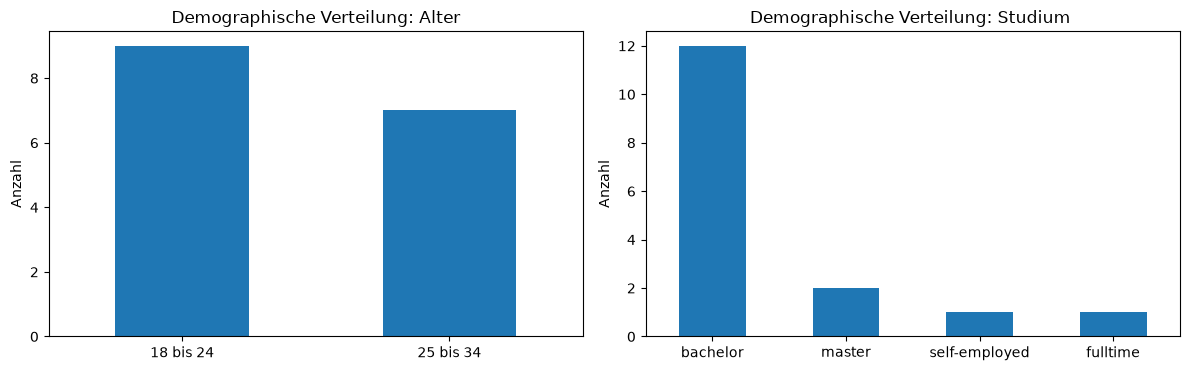

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

dfq["age"].value_counts().sort_index().plot(kind="bar", ax=axes[0], rot=0, title="Demographische Verteilung: Alter")
dfq["student_status"].value_counts().plot(   kind="bar",ax=axes[1], rot=0, title="Demographische Verteilung: Studium ")

axes[0].set_xlabel(" ")
axes[0].set_ylabel("Anzahl")
axes[1].set_xlabel(" ")
axes[1].set_ylabel("Anzahl")

plt.tight_layout()
#plt.savefig("demographische_verteilung.png", dpi=300, bbox_inches="tight")
plt.show()

In [145]:
# Studentenstatus
dfq["student_status"].value_counts()

student_status
bachelor         12
master            2
self-employed     1
fulltime          1
Name: count, dtype: int64

In [146]:
# Alter
dfq["age"].value_counts()

age
18 bis 24    9
25 bis 34    7
Name: count, dtype: int64

### 2.2 Auswertung NFC-K - Need for Cognition - Kurzfassung
- 4 Items, 7-Punkte-Likert-Skala
- Item 1 und 4 sind negativ ausgerichten und werden für die Auswertung invertiert, d.h. 8 - Antwortwert

Der NFC-K wird durch Mittelwertbildung ausgewertet

In [147]:
### NFC-K Errgebnis Berechnen
dfq["nfc_score"] = (
    8 - dfq["nfc_q1"]
    + dfq["nfc_q2"]
    + dfq["nfc_q3"]
    + (8 - dfq["nfc_q4"])
) / 4

# dfq["nfc_result"] # Ergebnis anzeigen
dfq["nfc_score"].describe()

count    16.000000
mean      4.140625
std       0.983060
min       2.250000
25%       3.437500
50%       4.000000
75%       4.750000
max       5.750000
Name: nfc_score, dtype: float64

***
### 2.3 Auswertung S-TiAS - Short Trust in Automation Scale
- 3 temporal versetzte Erhebnungen 
- `tias_0` Baseline
- `tias_1` nach 1. Teil
- `tias_2` nach 2. Teil
- Je 3 Items auf einer 7-Punkte-Likert-Skala
- Er enthält keine invertierten Items

Der STiA-S wird durch Mittelwertbildung ausgewertet


In [148]:
dfq["tias_bl_score"] = dfq[["tias_0_q1", "tias_0_q2", "tias_0_q3"]].mean(axis=1)
dfq["tias_1_score"] = dfq[["tias_1_q1", "tias_1_q2", "tias_1_q3"]].mean(axis=1)
dfq["tias_2_score"] = dfq[["tias_2_q1", "tias_2_q2", "tias_2_q3"]].mean(axis=1)

In [149]:
# Ordnen nach Highlight (HL) und Control Condition (CC)
dfq["tias_hl_score"] = np.where(
    dfq["group"].isin([1.0, 3.0]),
    dfq["tias_1_score"],
    dfq["tias_2_score"]
)

dfq["tias_cc_score"] = np.where(
    dfq["group"].isin([1.0, 3.0]),
    dfq["tias_2_score"],
    dfq["tias_1_score"]
)
dfq_tias = dfq[["tias_bl_score", "tias_cc_score", "tias_hl_score"]]
dfq_tias.describe()

,tias_bl_score,tias_cc_score,tias_hl_score
count,16.000000,16.000000,16.000000
mean,3.687500,3.833333,3.479167
std,1.151288,1.553967,1.712563
min,2.000000,1.000000,1.000000
25%,2.916667,3.000000,2.000000
50%,4.000000,4.166667,3.666667
75%,4.750000,4.750000,4.250000
max,5.000000,6.000000,7.000000


**Kurzinterpretation:** 
- Kaum unterschiede
- Range verbreitert sich, Varianz steigt von 1.15 auf 1.71
-> Prüfen, ob das signifikant ist

##### 2.3.1 Prüfen ob Zunahme der Streuung zw BL & Hl signifikant ist
-> Pitman-Morgan-Test (2-seitiger Hypothesentest, der Gleichheit der Varianzen abhängiger Stichproben zu zwei Messzeitpunkten untersucht)

In [150]:
paired = dfq[["tias_bl_score", "tias_hl_score"]].dropna()

bl = paired["tias_bl_score"].to_numpy()
hl = paired["tias_hl_score"].to_numpy()

# Deskriptive Werte
sd_bl = np.std(bl, ddof=1)
sd_hl = np.std(hl, ddof=1)

sd_diff = sd_hl - sd_bl
variance_ratio = np.var(hl, ddof=1) / np.var(bl, ddof=1)

# Pitman-Morgan-Test, Kernaussage: Gleiche Varianz := Korrelation (Summen, Differenz) = 0
score_sum = hl + bl
score_diff = hl - bl

r, p_two_sided = pearsonr(
    score_sum,
    score_diff,
    alternative="two-sided"
)

print(f"N = {len(paired)}")
print(f"SD Baseline = {sd_bl:.3f}")
print(f"SD HL = {sd_hl:.3f}")
print(f"SD-Differenz = {sd_diff:.3f}")
print(f"Varianzverhältnis HL zu BL = {variance_ratio:.3f}")
print(f"Pitman-Morgan: r = {r:.3f}, p = {p_two_sided:.4f}")

N = 16
SD Baseline = 1.151
SD HL = 1.713
SD-Differenz = 0.561
Varianzverhältnis HL zu BL = 2.213
Pitman-Morgan: r = 0.381, p = 0.1457


**Kurzinterpretation:** Der Effekt ist bei p = 0.146, α = 0.05 nicht signifikant.

***
### 2.4 Auswertung Übernahmeverhalten / Overreliance
- Es wurden 2 Teile à 7 Fragen beantwortet
    - Davon je 6 Multiple-Choice-Fragen & eine Freitextantwort
    - Jede Antwort hatte 4 vergleichbare Antwortmöglichkeiten plus die Option "Ich kenne die Antwort schon" auszuwählen (um den Einfluss von Vorwissen auszuschließen)
    - 2 der 6 Multiple-Choice-Fragen pro Teil waren korrekt
        - Teil A: `a_q1` und `a_q`
        - Teil B: `b_q1` und `b_q`

- Antworten wurden als **richtig**, **falsch**, **bekannt** und **andere** kategorisiert
    - **richtig**: die korrekte Antwort wurde gewählt
    - **falsch**: die inkorrekte Antwort wurde übernommen
    - **andere**: eine weitere inkorrekte Antwort wurde gewählt
    - **bekannt**: "Ich kenne die Antwort schon" wurde gewählt

#### 2.4.1 Data Preprocessing: Korrekte Antworten

In [151]:
# Sichten der korrekten Antworten
dfq[["username","a_q1", "a_q1_conf", "a_q5", "a_q5_conf", "b_q1", "b_q1_conf", "b_q2", "b_q2_conf"]] 

,username,a_q1,a_q1_conf,a_q5,a_q5_conf,b_q1,b_q1_conf,b_q2,b_q2_conf
0,p_03,richtig,4.0,richtig,4.0,richtig,3.0,richtig,3.0
1,p_06,richtig,4.0,richtig,3.0,richtig,2.0,richtig,4.0
2,p_15,richtig,7.0,richtig,6.0,richtig,6.0,richtig,6.0
3,p_09,richtig,6.0,richtig,5.0,richtig,6.0,richtig,5.0
4,p_02,richtig,6.0,richtig,5.0,richtig,5.0,richtig,5.0
5,p_08,richtig,5.0,richtig,2.0,richtig,3.0,richtig,2.0
6,p_17,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0
7,p_13,richtig,6.0,richtig,7.0,richtig,6.0,richtig,6.0
8,p_04,richtig,7.0,richtig,3.0,richtig,2.0,richtig,4.0
9,p_05,andere,7.0,richtig,7.0,richtig,6.0,richtig,7.0


**Kurzinterpretation:** 
- Zwei Personen haben bei einer korrekten Antwort eine falsche Antwort angegeben, obwohl es keine fehlerhafe Antwort im KI-Output für diese Frage gab. 
- Einer Person war eine Antwort bekannt.

In [152]:
#Entfernen der korrekten Antworten aus dem data frame
dfq.drop(columns=["a_q1", "a_q1_conf", "a_q5", "a_q5_conf",
          "b_q1", "b_q1_conf", "b_q2", "b_q2_conf"], inplace=True)

In [153]:
# Sichten der Antworten + Antwortkonfidenz aller übrigen Fragen
dfq[["username","a_q2", "a_q2_conf", "a_q3", "a_q3_conf", "a_q4", "a_q4_conf", "a_q6", "a_q6_conf","a_q7", "a_q7_conf", 
     "b_q3","b_q3_conf","b_q4", "b_q4_conf", "b_q5", "b_q5_conf", "b_q6", "b_q6_conf", "b_q7", "b_q7_conf"]] 

,username,a_q2,a_q2_conf,a_q3,a_q3_conf,a_q4,a_q4_conf,a_q6,a_q6_conf,a_q7,a_q7_conf,b_q3,b_q3_conf,b_q4,b_q4_conf,b_q5,b_q5_conf,b_q6,b_q6_conf,b_q7,b_q7_conf
0,p_03,falsch,4.0,falsch,4.0,falsch,4.0,falsch,4.0,falsch,4.0,falsch,3.0,falsch,3.0,falsch,1.0,falsch,4.0,falsch,4.0
1,p_06,bekannt,NaN,falsch,5.0,falsch,6.0,bekannt,NaN,falsch,4.0,falsch,5.0,falsch,3.0,bekannt,NaN,falsch,4.0,bekannt,NaN
2,p_15,richtig,7.0,falsch,7.0,richtig,3.0,richtig,5.0,richtig,5.0,falsch,7.0,falsch,7.0,falsch,7.0,falsch,7.0,falsch,7.0
3,p_09,richtig,5.0,falsch,5.0,richtig,6.0,richtig,4.0,richtig,5.0,falsch,7.0,richtig,3.0,falsch,7.0,richtig,5.0,richtig,6.0
4,p_02,andere,5.0,falsch,6.0,bekannt,NaN,falsch,6.0,falsch,5.0,falsch,5.0,falsch,2.0,bekannt,NaN,richtig,2.0,bekannt,NaN
5,p_08,falsch,2.0,falsch,3.0,falsch,3.0,falsch,3.0,falsch,3.0,falsch,5.0,richtig,5.0,falsch,3.0,falsch,2.0,falsch,5.0
6,p_17,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,6.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0
7,p_13,falsch,6.0,falsch,6.0,falsch,7.0,falsch,4.0,falsch,5.0,richtig,5.0,richtig,7.0,richtig,6.0,richtig,7.0,richtig,6.0
8,p_04,falsch,1.0,falsch,4.0,falsch,1.0,falsch,2.0,falsch,2.0,falsch,1.0,falsch,1.0,falsch,1.0,falsch,1.0,falsch,1.0
9,p_05,falsch,7.0,falsch,4.0,falsch,7.0,falsch,7.0,falsch,6.0,falsch,4.0,richtig,3.0,richtig,4.0,falsch,1.0,richtig,3.0


In [154]:
# Quote von richtig, falsch und bekannt pro Frage
cols = ["a_q2", "a_q3", "a_q4", "a_q6", "a_q7", "b_q3", "b_q4", "b_q5", "b_q6", "b_q7"]

q_quote = pd.DataFrame({
    col: dfq[col].value_counts(normalize=True).reindex(["richtig", "falsch", "bekannt", "andere"], fill_value=0) * 100
    for col in cols
}).T

q_quote.index.name = "Frage"
q_quote.round(2)

,richtig,falsch,bekannt,andere
Frage,,,,
a_q2,37.50,50.00,6.25,6.25
a_q3,31.25,68.75,0.00,0.00
a_q4,37.50,56.25,6.25,0.00
a_q6,37.50,56.25,6.25,0.00
a_q7,31.25,68.75,0.00,0.00
b_q3,18.75,81.25,0.00,0.00
b_q4,43.75,56.25,0.00,0.00
b_q5,31.25,50.00,18.75,0.00
b_q6,37.50,62.50,0.00,0.00


**Kurzinterpretation:** 
- `b_q5` (Abstand zw. Erde und Mond) und `b_q7` (Tiefe des Marianengraben) waren 18.75% (n = 3) und 12.5% (n = 2) der Teilnehmenden bekannt
- Im Fragenset A waren `a_q2`, `a_q4` und `a_q6` jeweils 6.25% (n = 1) der Teilnehmenden bekannt
- Alle übrigen Fragen waren nicht bekannt
- Insgesamt drei der Nennungen gehen auf `p_06` zurück
- Bei `a_q2` wurde einmal eine andere Antwort gewählt, die weder in der fehlerhaften Antwort, noch im Faktenabgleich vorkam.

In [155]:
# Aufteilen der Werte nach HL / CC 
# Entfernen von Antworten mit der Kategorie 

# Übrige Fragen in den Fragesets
a_cols = ["a_q2", "a_q3", "a_q4", "a_q6", "a_q7"]
b_cols = ["b_q3", "b_q4", "b_q5", "b_q6", "b_q7"]

a_conf_cols = [f"{c}_conf" for c in a_cols]
b_conf_cols = [f"{c}_conf" for c in b_cols]

# Sortieren nach Gruppe 1, 4: A = HL, B = CC und Gruppe 2, 3: B = HL, A = CC
a_is_hl = dfq["group"].isin([1.0, 4.0])
q_res = dfq[["username", "group"]].copy()

for i, (a_col, b_col, a_conf, b_conf) in enumerate(
    zip(a_cols, b_cols, a_conf_cols, b_conf_cols),
    start=1
):
    q_res[f"hl_q{i}"] = np.where(a_is_hl, dfq[a_col], dfq[b_col])
    q_res[f"hl_q{i}_conf"] = np.where(a_is_hl, dfq[a_conf], dfq[b_conf])

    q_res[f"cc_q{i}"] = np.where(a_is_hl, dfq[b_col], dfq[a_col])
    q_res[f"cc_q{i}_conf"] = np.where(a_is_hl, dfq[b_conf], dfq[a_conf])

q_res

,username,group,hl_q1,hl_q1_conf,cc_q1,cc_q1_conf,hl_q2,hl_q2_conf,cc_q2,cc_q2_conf,hl_q3,hl_q3_conf,cc_q3,cc_q3_conf,hl_q4,hl_q4_conf,cc_q4,cc_q4_conf,hl_q5,hl_q5_conf,cc_q5,cc_q5_conf
0,p_03,4,falsch,4.0,falsch,3.0,falsch,4.0,falsch,3.0,falsch,4.0,falsch,1.0,falsch,4.0,falsch,4.0,falsch,4.0,falsch,4.0
1,p_06,4,bekannt,NaN,falsch,5.0,falsch,5.0,falsch,3.0,falsch,6.0,bekannt,NaN,bekannt,NaN,falsch,4.0,falsch,4.0,bekannt,NaN
2,p_15,4,richtig,7.0,falsch,7.0,falsch,7.0,falsch,7.0,richtig,3.0,falsch,7.0,richtig,5.0,falsch,7.0,richtig,5.0,falsch,7.0
3,p_09,4,richtig,5.0,falsch,7.0,falsch,5.0,richtig,3.0,richtig,6.0,falsch,7.0,richtig,4.0,richtig,5.0,richtig,5.0,richtig,6.0
4,p_02,3,falsch,5.0,andere,5.0,falsch,2.0,falsch,6.0,bekannt,NaN,bekannt,NaN,richtig,2.0,falsch,6.0,bekannt,NaN,falsch,5.0
5,p_08,3,falsch,5.0,falsch,2.0,richtig,5.0,falsch,3.0,falsch,3.0,falsch,3.0,falsch,2.0,falsch,3.0,falsch,5.0,falsch,3.0
6,p_17,3,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,7.0,richtig,6.0
7,p_13,3,richtig,5.0,falsch,6.0,richtig,7.0,falsch,6.0,richtig,6.0,falsch,7.0,richtig,7.0,falsch,4.0,richtig,6.0,falsch,5.0
8,p_04,2,falsch,1.0,falsch,1.0,falsch,1.0,falsch,4.0,falsch,1.0,falsch,1.0,falsch,1.0,falsch,2.0,falsch,1.0,falsch,2.0
9,p_05,2,falsch,4.0,falsch,7.0,richtig,3.0,falsch,4.0,richtig,4.0,falsch,7.0,falsch,1.0,falsch,7.0,richtig,3.0,falsch,6.0


In [156]:
# Anteil "falsch" und "richtig" pro Frage über alle Teilnehmer
hl_cols = ["hl_q1", "hl_q2", "hl_q3", "hl_q4", "hl_q5"]
cc_cols = ["cc_q1", "cc_q2", "cc_q3", "cc_q4", "cc_q5"]

hl_answers = q_res[hl_cols].stack()
cc_answers = q_res[cc_cols].stack()

q_dist = pd.DataFrame({
    "HL in %": hl_answers.value_counts(normalize=True) * 100,
    "CC in %": cc_answers.value_counts(normalize=True) * 100
}).fillna(0).round(2)

q_dist

,HL in %,CC in %
andere,0.0,1.25
bekannt,5.0,5.00
falsch,45.0,73.75
richtig,50.0,20.00


#### 2.4.2 Effekt HL / CC auf Overreliance

In [157]:
# Quote "richtig" und "falsch" pro Person berechnen
# "bekannt" und fehlende Werte werden nicht in den Nenner aufgenommen.
hl_gueltig = q_res[hl_cols].isin(["richtig", "falsch", "andere"]).sum(axis=1)
cc_gueltig = q_res[cc_cols].isin(["richtig", "falsch", "andere"]).sum(axis=1)

q_res["hl_richtig_quote"] = q_res[hl_cols].eq("richtig").sum(axis=1) / hl_gueltig * 100
q_res["cc_richtig_quote"] = q_res[cc_cols].eq("richtig").sum(axis=1) / cc_gueltig * 100
q_res["hl_falsch_quote"] = q_res[hl_cols].eq("falsch").sum(axis=1) / hl_gueltig * 100
q_res["cc_falsch_quote"] = q_res[cc_cols].eq("falsch").sum(axis=1) / cc_gueltig * 100

In [158]:
# Vergleich der Quote pro Person mit gepaartem Wilcoxon-Text 
# Richtige Antworten:

w, p = wilcoxon(
    q_res["hl_richtig_quote"],
    q_res["cc_richtig_quote"]
)

print("Wilcoxon-Teststatistik: ", w, ";  P-Wert: ", p)

Wilcoxon-Teststatistik:  7.5 ;  P-Wert:  0.01322162850149682


In [159]:
# Falsche Antworten:
w, p = wilcoxon(
    q_res["hl_falsch_quote"],
    q_res["cc_falsch_quote"],
    alternative="less"
)
print("Wilcoxon-Teststatistik: ", w, ";  P-Wert: ", p)

Wilcoxon-Teststatistik:  8.5 ;  P-Wert:  0.008218057487263623


**Kurzinterpretation:** 
- Der Effekt bezüglich des Übernahmeverhaltens ist mit  p = 0.008 bei Signifikanzniveau α = 0.05 statistisch stark signifikant.
- Auch der Effekt auf den Anteil richtiger Antworten unterscheidet sich mit p = 0.014 signifikant zwischen HL und CC.

#### 2.4.3 Reihenfolge-Effekte

In [160]:
# Daten ins Long-Format bringen
a_long = dfq[
    ["username", "group", "hl_order"] + a_cols
].melt(
    id_vars=["username", "group", "hl_order"],
    var_name="question",
    value_name="answer"
)
a_long["condition"] = np.where(
    a_long["group"].isin([1, 4]), "HL", "CC"
)

b_long = dfq[
    ["username", "group", "hl_order"] + b_cols
].melt(
    id_vars=["username", "group", "hl_order"],
    var_name="question",
    value_name="answer"
)
b_long["condition"] = np.where(
   b_long["group"].isin([2, 3]), "HL", "CC"
)

over_long = pd.concat([a_long, b_long], ignore_index=True)
over_long["answer"] = (
    over_long["answer"]
    .astype("string")
    .str.strip()
    .str.lower()
)

cc_long = over_long[
    (over_long["condition"] == "CC")
    & over_long["answer"].isin(["falsch", "richtig", "andere"])
].copy()

# Zielvariable: 1 = fehlerhafte KI-Antwort übernommen
cc_long["overreliance"] = (
    cc_long["answer"] == "falsch"
).astype(int)

# H3-Prädiktor: 1 = HL zuerst, 0 = CC zuerst
cc_long["hl_first"] = (
    cc_long["hl_order"].astype(str) == "1"
).astype(int)

cc_long["username"] = cc_long["username"].astype(str)
cc_long["question"] = cc_long["question"].astype(str)

# Deskriptive Ergebnisse
deskriptiv_h3 = (
    cc_long
    .groupby("hl_first")
    .agg(
        Teilnehmende=("username", "nunique"),
        Antworten=("overreliance", "size"),
        Overreliance_Fälle=("overreliance", "sum"),
        Overreliance_Prozent=("overreliance", lambda x: x.mean() * 100)
    )
    .rename(index={0: "CC zuerst", 1: "HL zuerst"})
)

display(deskriptiv_h3.round(2))

# Bayesianisches logistisches Mixed-Effects-Modell
modell_h3 = BinomialBayesMixedGLM.from_formula(
    formula="overreliance ~ hl_first",
    vc_formulas={
        "Teilnehmende": "0 + C(username)",
        "Fragen": "0 + C(question)"
    },
    data=cc_long,
    vcp_p=0.5,
    fe_p=2
)

ergebnis_h3 = modell_h3.fit_vb()

# H3-Effekt auslesen
i = modell_h3.exog_names.index("hl_first")
beta = ergebnis_h3.fe_mean[i]
sd = ergebnis_h3.fe_sd[i]

odds_ratio = np.exp(beta)
untergrenze = np.exp(beta - 1.96 * sd)
obergrenze = np.exp(beta + 1.96 * sd)

# H3 erwartet Beta < 0 beziehungsweise OR < 1
p_h3 = norm.cdf(0, loc=beta, scale=sd)
print(ergebnis_h3.summary())

print(f"Beta: {beta:.3f}")
print(f"Odds Ratio: {odds_ratio:.3f}")
print(
    "Approximatives 95-%-Glaubwürdigkeitsintervall: "
    f"[{untergrenze:.3f}, {obergrenze:.3f}]"
)
print(f"P(Beta < 0 | Daten): {p_h3:.1%}")

,Teilnehmende,Antworten,Overreliance_Fälle,Overreliance_Prozent
hl_first,,,,
CC zuerst,8,38,33,86.84
HL zuerst,8,38,26,68.42


                Binomial Mixed GLM Results
             Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
-----------------------------------------------------------
Intercept       M     2.2994   0.3557                      
hl_first        M    -0.7920   0.4733                      
Teilnehmende    V     0.6148   0.1563 1.849   1.353   2.528
Fragen          V    -0.3234   0.2161 0.724   0.470   1.115
Parameter types are mean structure (M) and variance
structure (V)
Variance parameters are modeled as log standard deviations
Beta: -0.792
Odds Ratio: 0.453
Approximatives 95-%-Glaubwürdigkeitsintervall: [0.179, 1.145]
P(Beta < 0 | Daten): 95.3%


***
### 2.5 Korrelationen mit NFC und Overreliance


In [161]:
# Werte aus dfq und q_res zusammenführen
corr_df = dfq[["username", "nfc_score"]].merge(
    q_res[[
        "username",
        "hl_richtig_quote",
        "cc_richtig_quote",
        "hl_falsch_quote",
        "cc_falsch_quote"
    ]],
    on="username",
    how="inner"
)

# Overreliance-Maß:
corr_df["delta_overreliance"] = (
    corr_df["cc_falsch_quote"] - corr_df["hl_falsch_quote"]
)

# optional: Gesamtfehlerquote
corr_df["gesamt_falsch_quote"] = (
    corr_df[["hl_falsch_quote", "cc_falsch_quote"]].mean(axis=1)
)

In [162]:
print(corr_df.shape)
corr_df = corr_df.sort_values("username")
print(corr_df[["username", "nfc_score", "hl_falsch_quote", "cc_falsch_quote", "delta_overreliance"]])

(16, 8)
   username  nfc_score  hl_falsch_quote  cc_falsch_quote  delta_overreliance
12     p_01       3.25        20.000000            100.0           80.000000
4      p_02       2.25        66.666667             75.0            8.333333
0      p_03       4.50       100.000000            100.0            0.000000
8      p_04       5.75       100.000000            100.0            0.000000
9      p_05       4.75        40.000000            100.0           60.000000
1      p_06       4.00       100.000000            100.0            0.000000
5      p_08       4.75        80.000000            100.0           20.000000
3      p_09       4.75        20.000000             40.0           20.000000
13     p_10       3.25        60.000000            100.0           40.000000
11     p_11       3.25       100.000000             80.0          -20.000000
14     p_12       3.50         0.000000             50.0           50.000000
7      p_13       4.00         0.000000            100.0          10

In [163]:
heatmap_df = corr_df[[
    "nfc_score",
    "hl_falsch_quote",
    "cc_falsch_quote",
    "gesamt_falsch_quote",
    "delta_overreliance"
]]

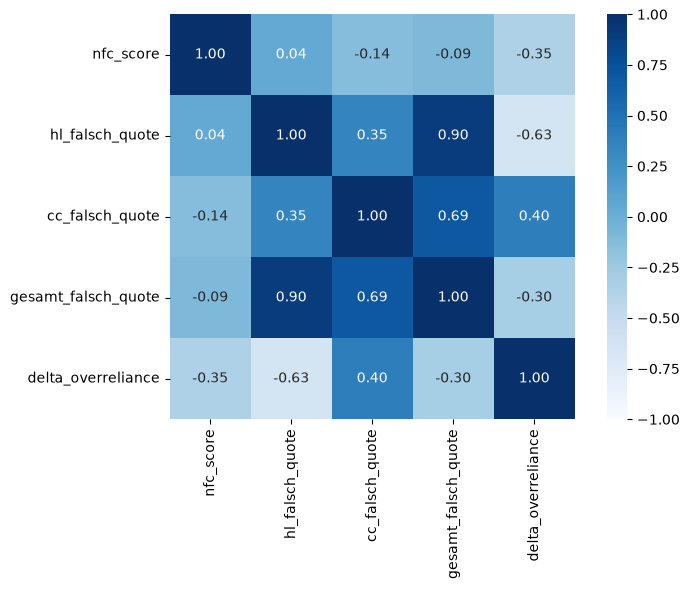

In [164]:
corr = heatmap_df.corr(method="spearman", numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.tight_layout()
plt.savefig("korrelationsmatrix_overreliance.png", dpi=500, bbox_inches="tight")
plt.show()

**Kurzinterpretation:**
- `nfc_score` korreliert negativ mit `delta_overreliance`, d.h. ein Teilnehmer mit einem höherem NFC-Score machen tendenziell weniger zusätzliche Fehler in der CC als in HL

***
### 3.4 Korrelation von Antwortkonfidenz Overreliance
- Antwortkonfidenz wurde nach jeder Frage auf eine 7-Punkte Likert-Skala angegeben.
- Daten sind ordinal skaliert

In [165]:
# Erstellen des zusammengefassen df
hl_conf_cols = sorted(
    [c for c in q_res.columns if re.match(r"hl_q\d+_conf$", c)],
    key=lambda x: int(re.search(r"q(\d+)", x).group(1))
)

cc_conf_cols = sorted(
    [c for c in q_res.columns if re.match(r"cc_q\d+_conf$", c)],
    key=lambda x: int(re.search(r"q(\d+)", x).group(1))
)

conf_long = q_res[["username"] + hl_conf_cols + cc_conf_cols].melt(
    id_vars="username",
    value_vars=hl_conf_cols + cc_conf_cols,
    var_name="item",
    value_name="confidence"
)

conf_long["condition"] = conf_long["item"].str.extract(r"^(hl|cc)")
conf_long["condition"] = conf_long["condition"].replace({
    "hl": "HL",
    "cc": "CC"
})

conf_long["question"] = conf_long["item"].str.extract(r"q(\d+)").astype(int)

#conf_long.head(20)

In [166]:
# Häufigkeiten 
conf_counts = pd.crosstab(
    conf_long["condition"],
    conf_long["confidence"],
    normalize="index"
) * 100

conf_counts.round(1)

confidence,1.0,2.0,3.0,4.0,5.0,6.0,7.0
condition,,,,,,,
CC,7.9,6.6,15.8,10.5,19.7,19.7,19.7
HL,7.9,9.2,10.5,17.1,25.0,15.8,14.5


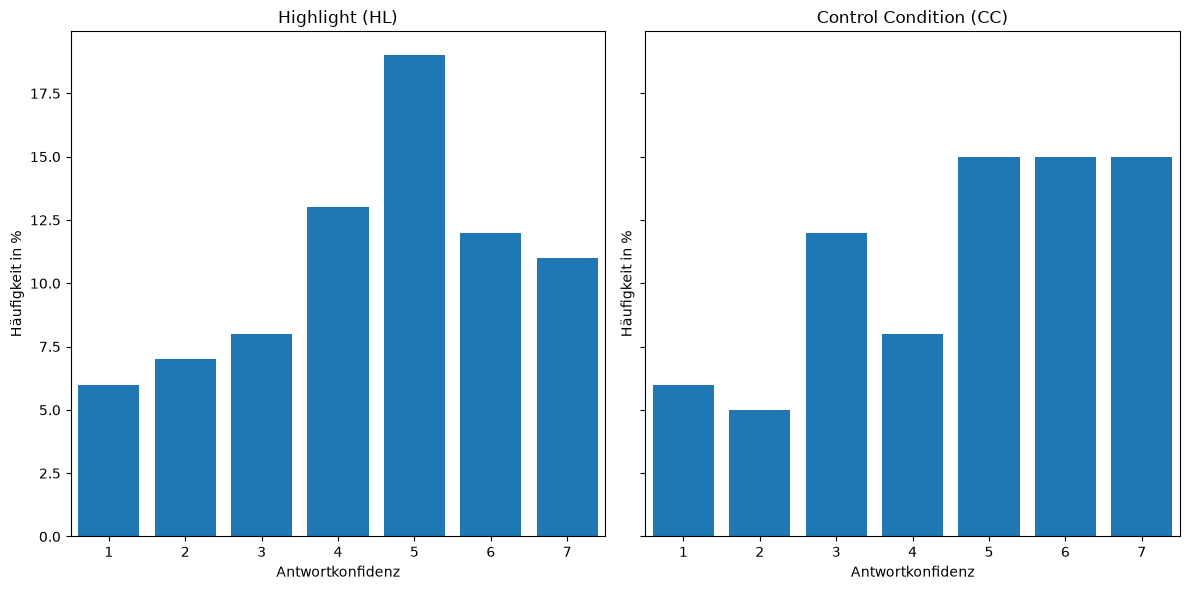

In [167]:
# Visualisierung der Verteilung als Balkendiagramm

hl_conf_cols = sorted(
    [c for c in q_res.columns if re.match(r"hl_q\d+_conf$", c)],
    key=lambda x: int(re.search(r"q(\d+)", x).group(1))
)

cc_conf_cols = sorted(
    [c for c in q_res.columns if re.match(r"cc_q\d+_conf$", c)],
    key=lambda x: int(re.search(r"q(\d+)", x).group(1))
)

# Alle Konfidenzwerte pro Bedingung in eine lange Liste
hl_vals = q_res[hl_conf_cols].stack().dropna().astype(int)
cc_vals = q_res[cc_conf_cols].stack().dropna().astype(int)

# Häufigkeiten 1 bis 7
hl_counts = hl_vals.value_counts().sort_index().reindex(range(1, 8), fill_value=0)
cc_counts = cc_vals.value_counts().sort_index().reindex(range(1, 8), fill_value=0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

axes[0].bar(hl_counts.index, hl_counts.values)
axes[0].set_title("Highlight (HL)")
axes[0].set_xlabel("Antwortkonfidenz")
axes[0].set_ylabel("Häufigkeit in %")
axes[0].set_xticks(range(1, 8))
axes[0].set_xlim(0.5, 7.5)

axes[1].bar(cc_counts.index, cc_counts.values)
axes[1].set_title("Control Condition (CC)")
axes[1].set_xlabel("Antwortkonfidenz")
axes[1].set_ylabel("Häufigkeit in %")
axes[1].set_xticks(range(1, 8))
axes[1].set_xlim(0.5, 7.5)

plt.tight_layout()
plt.savefig("konfidenz_hl_cc_bar.png", dpi=300, bbox_inches="tight")
plt.show()

**Kurzinterpretation:** Verteilung etwas flacher in CC. Werte zwischen 5-7 jedoch gleich. 

***
### 3.4.1 Signifikanz der Unterschiede HL / CC - Wilcoxon
Median von HL vs. CC testen als gepaarter, nichtparametrischer Test (Wilcoxon)

In [168]:
conf_person = q_res[["username"]].copy()

conf_person["hl_conf_median"] = q_res[hl_conf_cols].median(axis=1)
conf_person["cc_conf_median"] = q_res[cc_conf_cols].median(axis=1)

test = wilcoxon(
    conf_person["hl_conf_median"],
    conf_person["cc_conf_median"],
    zero_method="wilcox"
)

print(f"Wilcoxon HL vs. CC: W = {test.statistic:.3f}, p = {test.pvalue:.3f}")

Wilcoxon HL vs. CC: W = 41.000, p = 0.465


**Kurzinterpretation:** Nicht signifikant

***
### 3.4.2 Signifikanz der Unterschiede HL / CC - Binomialtest
Prüft, ob mehr Personen in CC höhere oder niedrigere Konfidenz hatten als in HL.

In [169]:
# Binomtest
diff = conf_person["cc_conf_median"] - conf_person["hl_conf_median"]

n_pos = (diff > 0).sum()
n_neg = (diff < 0).sum()
n_nonzero = n_pos + n_neg

res = binomtest(n_pos, n_nonzero, p=0.5, alternative="two-sided")

print(f"CC > HL: {n_pos}")
print(f"HL > CC: {n_neg}")
print(f"p = {res.pvalue:.3f}")

CC > HL: 8
HL > CC: 6
p = 0.791


**Kurzinterpretation:** Keine signifikatnen Unterschiede. 2x sind HL gleich CC

***
***
# 4. Interaktionsdaten

In [170]:
# Datenimport
url = "https://raw.githubusercontent.com/carinaburana/overreliance-study/main/interaction_data_clean.csv"
dfi = pd.read_csv(url)

### 4.1 EDA - Explorative Datenanalyse
Ziel: Besonderheiten, fehlende Werte, Duplikate identifizieren

In [171]:
dfi.head()

,event_type,element_id,timestamp,url,phase,username,hover_duration_ms,pasted_content,message,group,highlighted_text
0,source-link-hover-end,source-link,2026-06-27 13:25:29.82561+00,https://de.wikipedia.org/wiki/Hubble-Weltraumt...,part1,p_17,50188.0,NaN,NaN,NaN,NaN
1,source-link-click,source-link,2026-06-27 13:34:07.381738+00,https://de.wikipedia.org/wiki/Ellsberg-Paradoxon,part2,p_17,NaN,NaN,NaN,NaN,NaN
2,source-link-hover-start,source-link,2026-06-27 13:34:44.502775+00,https://de.wikipedia.org/wiki/Ellsberg-Paradoxon,part2,p_17,NaN,NaN,NaN,NaN,NaN
3,source-link-hover-end,source-link,2026-06-27 13:30:35.247257+00,https://de.wikipedia.org/wiki/Standardatmosph%...,part2,p_17,501.0,NaN,NaN,NaN,NaN
4,paste,chat-input,2026-06-27 13:36:49.55042+00,NaN,part2,p_17,NaN,Wie lange dauert ein regulärer Umlauf des Hall...,NaN,NaN,NaN


**Kurzbeschreibung:**
-  `event_type` Art der Interkation z.B. Quelllink öffnen, Quelllink hovern, Text Kopieren, Text in Eingabefeld einfügen
-  `element_id` Elementtyp
-  `timestamp` Zeitpunkt des Aufretens
-  `url` Adresse eine Quelllinks 
-  `phase` 1. oder 2. Teil, Hilfskategorie um Zuordnung zu erleichtern
-  `username` anonymisiertes Kürzel, passend zu Fragebogendaten
-  `hover_duration_ms` Dauer die Links gehovert wurden in Millisekunden
-  `pasted_content` Eingefügter Text in Eingabefeld
-  `message` abgesendete Nachricht
-  `group` Gruppe
-  `highlighted_text` spezielles Highlight, das gehovert wurde 


In [172]:
# Duplikate und participant_id entfernen
#dfi.drop(columns=["participant_id", "group.1", "timestamp.1"], inplace=True)

In [173]:
# Anzahl Werte in highlighted_text - in 
# dfi["highlighted_text"].notna().sum()

# Ausgabe der Werte in highlighted_text Werte gespeichert wurden
dfi["highlighted_text"].dropna()

219     stark davon abhängen, wie Wahrscheinlichkeiten...
220     stark davon abhängen, wie Wahrscheinlichkeiten...
246     stark davon abhängen, wie Wahrscheinlichkeiten...
258                                              86 Jahre
270                             eine Dose Campbell's Soup
282                                              86 Jahre
389     Rebound-Effekt verstanden werden, bei dem eine...
525     sodass die erwarteten Einsparungen geringer au...
528     sodass die erwarteten Einsparungen geringer au...
529     sodass die erwarteten Einsparungen geringer au...
628                                        102.325 Pascal
637     stark davon abhängen, wie Wahrscheinlichkeiten...
1137    sodass die erwarteten Einsparungen geringer au...
1141    sodass die erwarteten Einsparungen geringer au...
1148    Rebound-Effekt verstanden werden, bei dem eine...
Name: highlighted_text, dtype: str

In [174]:
dfi.dtypes

event_type               str
element_id               str
timestamp                str
url                      str
phase                    str
username                 str
hover_duration_ms    float64
pasted_content           str
message                  str
group                float64
highlighted_text         str
dtype: object

***
### 4.2 Analyse Interaktionsdaten
- Anzahl gesendeter Nachrichten
- Kopieren von Antworten
- Hovern von Quellenlinks
- Klicken von Quellenlinks

In [175]:
# Anzahl Werte pro User, Diskretisieren und source_hovered
counts = (
    dfi.groupby("username")
       .agg(
           interactions=("username", "size"),
           messages_sent=("event_type", lambda x: (x == "message-send").sum()),
           copied=("event_type", lambda x: (x == "copy").sum()),
           pasted=("event_type", lambda x: (x == "paste").sum()),
           source_hovered=("hover_duration_ms", lambda x: (x >= 200).sum()),
           dauer_hover_mean=("hover_duration_ms", lambda x: x[x >= 200].mean()),
           source_clicks=("event_type", lambda x: (x == "source-link-click").sum()) 
       )
       .reset_index()
)

counts

,username,interactions,messages_sent,copied,pasted,source_hovered,dauer_hover_mean,source_clicks
0,p_01,70,18,0,0,1,383.000000,0
1,p_02,56,12,2,11,0,NaN,0
2,p_03,44,14,2,14,2,283.000000,0
3,p_04,187,23,8,19,17,1226.411765,0
4,p_05,56,18,2,17,1,350.000000,0
5,p_06,44,11,2,11,2,628.500000,0
6,p_08,33,14,2,14,0,NaN,0
7,p_09,232,17,3,17,39,1104.615385,28
8,p_10,144,14,4,14,20,19458.750000,16
9,p_11,99,18,9,17,1,233.000000,0


**Kurzinterpretation:** 
- Zwei Teilnehmer haben weniger als 14 Nachrichten gesendet, das deckt sich mit der Anzahl "Ich kenne die Antwort schon"-Angaben im Quiz
- 12 der 16 Teilnehmer haben mehr als 14 Nachrichten gesendet
- 5 Personen haben nur Text eingefügt (anzahl_message-sent = anzahl_paste)
- 5 Personen haben weniger als 2x Text kopiert (relevant für Freitextaufgabe)
- 1 Person hat nie Text eingefügt, 1 Person nur einmal, 10 min. 14x
- 6 Personen haben Quellenlinks angeklickt -> untersuchen ob `nfc_score` und Overreliance mit Wert korreliert

- Höchste durchschnittliche Hoverdauer: 19.5 s -> kann jedoch auch andere Ursache haben!

***
### 4.3 Korrelation NFC -> Überprüfungsverhalten

In [176]:
# Werte extrahieren
check_df = (
    dfi
    .groupby("username")
    .agg(
        source_clicks=(
            "event_type",
            lambda x: (x == "source-link-click").sum()
        ),
        source_hovered=(
            "hover_duration_ms",
            lambda x: (x >= 200).sum()
        ),
        dauer_hover_mean=(
            "hover_duration_ms",
            lambda x: x[x >= 200].mean()
        )
    )
    .reset_index()
)

check_df.head()


,username,source_clicks,source_hovered,dauer_hover_mean
0,p_01,0,1,383.000000
1,p_02,0,0,NaN
2,p_03,0,2,283.000000
3,p_04,0,17,1226.411765
4,p_05,0,1,350.000000


In [177]:
# Dataframes mergen
corr_df = dfq[["username", "nfc_score"]].merge(
    q_res[[
        "username",
        "hl_richtig_quote",
        "cc_richtig_quote",
        "hl_falsch_quote",
        "cc_falsch_quote"
    ]],
    on="username",
    how="inner"
)

corr_df["overreliance"] = corr_df["cc_falsch_quote"]

corr_df["delta_overreliance"] = (
    corr_df["cc_falsch_quote"] - corr_df["hl_falsch_quote"]
)

corr_df["ges_falsch_quote"] = (
    corr_df[["hl_falsch_quote", "cc_falsch_quote"]].mean(axis=1)
)

# Prüfverhalten hinzufügen
corr_df = corr_df.merge(
    check_df,
    on="username",
    how="inner"
)

corr_df.head()

,username,nfc_score,hl_richtig_quote,cc_richtig_quote,hl_falsch_quote,cc_falsch_quote,overreliance,delta_overreliance,ges_falsch_quote,source_clicks,source_hovered,dauer_hover_mean
0,p_03,4.50,0.000000,0.0,100.000000,100.0,100.0,0.000000,100.000000,0,2,283.000000
1,p_06,4.00,0.000000,0.0,100.000000,100.0,100.0,0.000000,100.000000,0,2,628.500000
2,p_15,3.50,80.000000,0.0,20.000000,100.0,100.0,80.000000,60.000000,1,5,552.600000
3,p_09,4.75,80.000000,60.0,20.000000,40.0,40.0,20.000000,30.000000,28,39,1104.615385
4,p_02,2.25,33.333333,0.0,66.666667,75.0,75.0,8.333333,70.833333,0,0,NaN


##### 4.3.1 Korrelationsmatrix

In [178]:
# Anzahl Daten prüfen
print(corr_df.shape)
print(corr_df["username"].nunique())

(16, 12)
16


In [179]:
# Korrelationsmatrix
vars_for_corr = [
    "nfc_score",
    "source_clicks",
    "source_hovered",
    "dauer_hover_mean",
    "overreliance",
    "delta_overreliance",
    "ges_falsch_quote"
]

corr_data = corr_df[vars_for_corr]
corr_matrix = corr_data.corr(method="spearman", numeric_only=True)
#corr_matrix

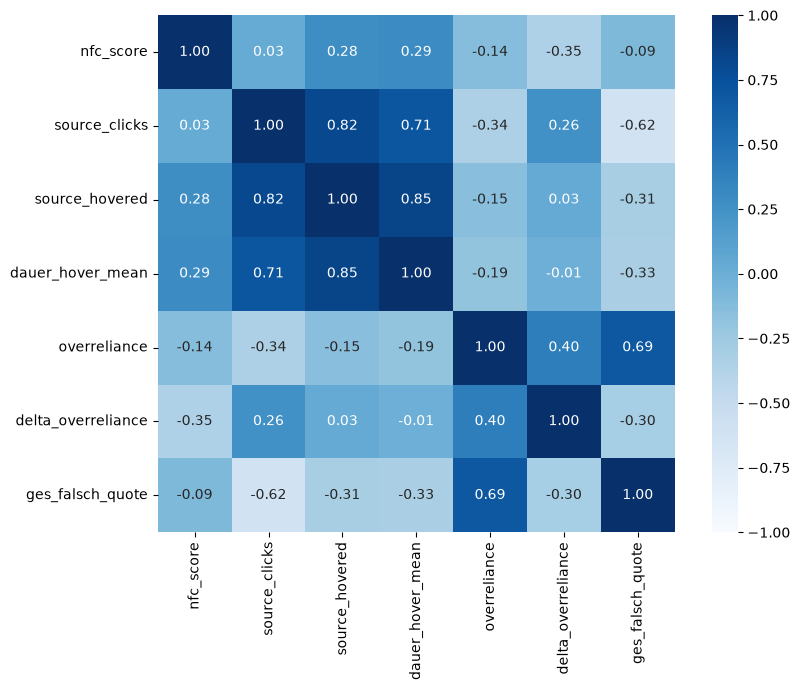

In [180]:
# Heatmap
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    center=0,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.tight_layout()
plt.savefig("korrelationsmatrix_nfc_pruefverhalten_overreliance.png", dpi=300, bbox_inches="tight")
plt.show()

##### 4.3.2 Interferenzstatistische Analyse

In [192]:
# Gerichtete Spearman-Korrelationen für H10 bis H13
tests = {
    "H10": ("dauer_hover_mean", "ges_falsch_quote", "less"),
    "H11": ("nfc_score", "cc_falsch_quote", "less"),
    "H12-clicks": ("nfc_score", "source_clicks", "greater"),
    "H12-hovers": ("nfc_score", "source_hovered", "greater"),
    "H13": ("nfc_score", "delta_overreliance", "less"),
}

results = []

for hypothese, (x, y, direction) in tests.items():
    # Nur vollständige Wertepaare verwenden
    d = corr_df[[x, y]].dropna()

    # Zweiseitiger Spearman-Test
    rho, p_zweiseitig = spearmanr(d[x], d[y])

    # Gerichteter Spearman-Test entsprechend der Hypothese
    _, p_gerichtet = spearmanr(
        d[x],
        d[y],
        alternative=direction
    )

    results.append([
        hypothese,
        x,
        y,
        len(d),
        rho,
        p_zweiseitig,
        p_gerichtet
    ])

korrelationstabelle = pd.DataFrame(
    results,
    columns=[    "Hypothese", "Variable_X", "Variable_Y", "N", "rho", "p_zweiseitig", "p_gerichtet"
    ]
)

# Holm-Korrektur über die fünf gerichteten Hypothesentests
holm_ergebnisse = multipletests(
    korrelationstabelle["p_gerichtet"],
    alpha=0.05,
    method="holm"
)

korrelationstabelle["p_Holm"] = holm_ergebnisse[1]
korrelationstabelle.round(3)

,Hypothese,Variable_X,Variable_Y,N,rho,p_zweiseitig,p_gerichtet,p_Holm
0,H10,dauer_hover_mean,ges_falsch_quote,14,-0.327,0.253,0.127,0.506
1,H11,nfc_score,cc_falsch_quote,16,-0.139,0.608,0.304,0.608
2,H12-clicks,nfc_score,source_clicks,16,0.027,0.920,0.460,0.608
3,H12-hovers,nfc_score,source_hovered,16,0.278,0.297,0.149,0.506
4,H13,nfc_score,delta_overreliance,16,-0.350,0.184,0.092,0.461


***
### 4.4 Korrelation Kondition -> Überprüfungsverhalten

In [ ]:
# H7 und H8
# Inner Join
i = dfi.merge(
    dfq[["username", "hl_order"]],
    on="username",
    how="inner"
)

# Zuordnung der beiden Phasen zur jeweiligen Kondition:
i["condition"] = np.where(
    (i["phase"].eq("part1")& i["hl_order"].eq(1))|
    (i["phase"].eq("part2")& i["hl_order"].eq(2)),
    "HL","CC"
)

# Klicks und gültige Hover-Ereignisse pro Person und Kondition
i_person = (
    i.groupby(["username", "condition"])
    .agg(
        source_clicks=("event_type", lambda x: (x == "source-link-click").sum()),
        source_hovered=( "hover_duration_ms",lambda x: (x >= 200).sum())
    )
    .reset_index()
)

# Deskriptive Ergebnisse nach Kondition
i_deskriptiv = (
    i_person.groupby("condition")
    .agg(
        N=("username", "nunique"),

        clicks_M=("source_clicks", "mean"),
        clicks_SD=("source_clicks", "std"),
        clicks_Mdn=("source_clicks", "median"),
        clicks_P25=("source_clicks", lambda x: x.quantile(0.25)),
        clicks_P75=("source_clicks", lambda x: x.quantile(0.75)),

        hover_M=("source_hovered", "mean"),
        hover_SD=("source_hovered", "std"),
        hover_Mdn=("source_hovered", "median"),
        hover_P25=("source_hovered", lambda x: x.quantile(0.25)),
        hover_P75=("source_hovered", lambda x: x.quantile(0.75))
    )
    .reindex(["HL", "CC"])
)
display(i_deskriptiv.round(3))

# Gepaarte Tests
i_wide = i_person.pivot(
    index="username",
    columns="condition",
    values=["source_clicks", "source_hovered"]
)

tests_i = {
    "H7-clicks": "source_clicks",
    "H8-hover": "source_hovered"
}

results_i = []

for hypothese, variable in tests_i.items():

    paired = i_wide[variable][["HL", "CC"]].dropna()
    differenz = paired["HL"] - paired["CC"]

    # Gerichteter gepaarter Wilcoxon-Test HL > CC
    wilcox = wilcoxon(paired["HL"], paired["CC"],
        alternative="greater",
        zero_method="wilcox",
        method="approx"
    )

    n_hl_groesser = int((differenz > 0).sum())
    n_cc_groesser = int((differenz < 0).sum())
    n_gleich = int((differenz == 0).sum())

    # Exakter gerichteter Vorzeichentest
    if (n_hl_groesser + n_cc_groesser) > 0:
        p_vorzeichen = binomtest(
            n_hl_groesser,
            n_hl_groesser + n_cc_groesser,
            p=0.5,
            alternative="greater"
        ).pvalue
    else:
        p_vorzeichen = np.nan

    results_i.append([ hypothese,  len(paired),  
                      paired["HL"].mean(),  paired["CC"].mean(),  paired["HL"].median(),  paired["CC"].median(),
                        wilcox.statistic, wilcox.pvalue,  n_hl_groesser, n_cc_groesser, n_gleich,  p_vorzeichen
    ])

i_tests = pd.DataFrame(
    results_i,
    columns=[
        "Hypothese", "N", "M_HL", "M_CC", "Mdn_HL", "Mdn_CC", "W", "p_Wilcoxon", 
        "HL_groesser", "CC_groesser", "HL_gleich_CC","p_vztest"
])

# Holm-Korrektur über die beiden primären Wilcoxon-Tests H7 und H8
signifikant_holm, p_holm, _, _ = multipletests(
    i_tests["p_Wilcoxon"],
    alpha=0.05,
    method="holm"
)

i_tests["p_Holm"] = p_holm
i_tests = i_tests[
    ["Hypothese",  "N", "M_HL", "M_CC", "Mdn_HL", "Mdn_CC", "W", "p_Wilcoxon", "p_Holm",
     "HL_groesser", "CC_groesser", "HL_gleich_CC", "p_vztest"
    ]
]
display(i_tests.round(3))

,N,clicks_M,clicks_SD,clicks_Mdn,clicks_P25,clicks_P75,hover_M,hover_SD,hover_Mdn,hover_P25,hover_P75
condition,,,,,,,,,,,
HL,16,2.812,5.218,0.0,0.0,2.25,4.375,6.946,1.0,0.00,4.00
CC,16,2.312,4.658,0.0,0.0,1.75,4.625,6.702,1.0,0.75,6.25


,Hypothese,N,M_HL,M_CC,Mdn_HL,Mdn_CC,W,p_Wilcoxon,p_Holm,HL_groesser,CC_groesser,HL_gleich_CC,p_vztest
0,H7-clicks,16,2.812,2.312,0.0,0.0,13.5,0.264,0.527,4,2,10,0.344
1,H8-hover,16,4.375,4.625,1.0,1.0,44.5,0.528,0.528,6,7,3,0.709


***Kurzinterpretation:*** 
- Klick-Median bei beiden Konditionen 0
- Hover-Median bei beiden Konditionen 1
- keine Signifikanz
- Stark schiefe Verteilung